In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Bước 1: Load dữ liệu và kiểm tra cấu trúc file
csv_path = 'Clinical Text Data.csv'
for enc in ['utf-8-sig', 'cp1252', 'latin1']:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        break
    except UnicodeDecodeError:
        continue
else:
    raise UnicodeDecodeError('csv', b'', 0, 1, 'Không đọc được file CSV với các encoding đã thử')

print('Các cột trong file CSV:', df.columns.tolist())
print('Số lượng mẫu theo nhãn:')
print(df['Label'].value_counts())

required_columns = {'Text', 'Label'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise KeyError(f'File CSV thiếu cột: {missing_columns}. Các cột hiện có: {df.columns.tolist()}')

Các cột trong file CSV: ['Id', 'Label', 'Text']
Số lượng mẫu theo nhãn:
Label
Thyroid Research      2810
Colorectal Studies    2511
Pulmonary Research    2180
Name: count, dtype: int64


## Bước 2: Làm sạch dữ liệu

In [2]:
# Bước 2: Làm sạch dữ liệu
df = df[['Text', 'Label']].dropna().copy()
df['Text'] = df['Text'].astype(str).str.lower()

print(df.head())

                                                Text             Label
0  thyroid surgery in  children in a single insti...  Thyroid Research
1  " the adopted strategy was the same as that us...  Thyroid Research
2  coronary arterybypass grafting thrombosis ï¬b...  Thyroid Research
3   solitary plasmacytoma sp of the skull is an u...  Thyroid Research
4   this study aimed to investigate serum matrix ...  Thyroid Research


## Bước 3: Chia tập dữ liệu

In [3]:
# Bước 3: Chia tập dữ liệu
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Text'],
    df['Label'],
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

print('Kích thước tập train:', X_train_text.shape[0])
print('Kích thước tập test:', X_test_text.shape[0])

Kích thước tập train: 6000
Kích thước tập test: 1501


## Bước 4: Dự đoán và đánh giá

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


--- KẾT QUẢ HUẤN LUYỆN NAIVE BAYES ---
Accuracy: 0.8927
                    precision    recall  f1-score   support

Colorectal Studies       0.88      0.79      0.83       503
Pulmonary Research       1.00      1.00      1.00       436
  Thyroid Research       0.83      0.90      0.86       562

          accuracy                           0.89      1501
         macro avg       0.90      0.90      0.90      1501
      weighted avg       0.89      0.89      0.89      1501



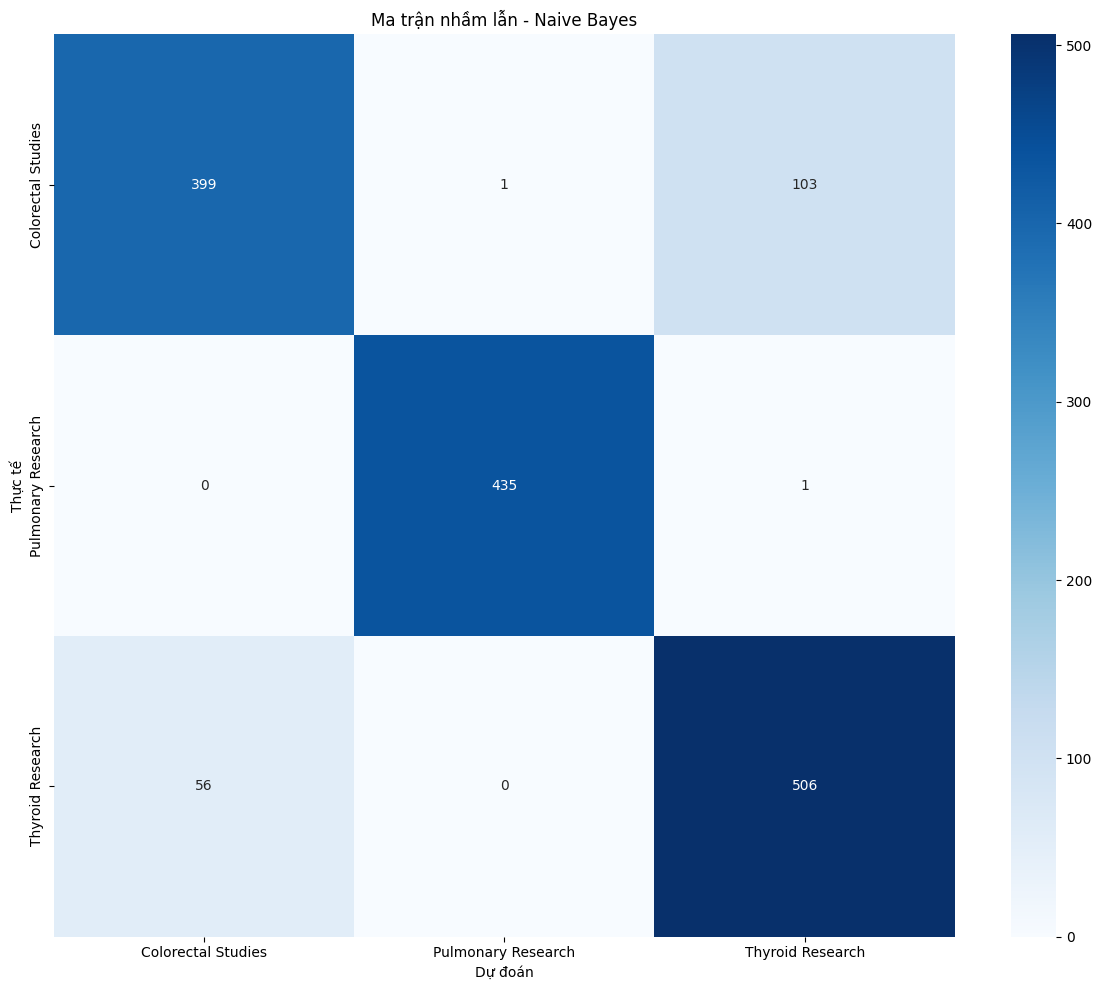

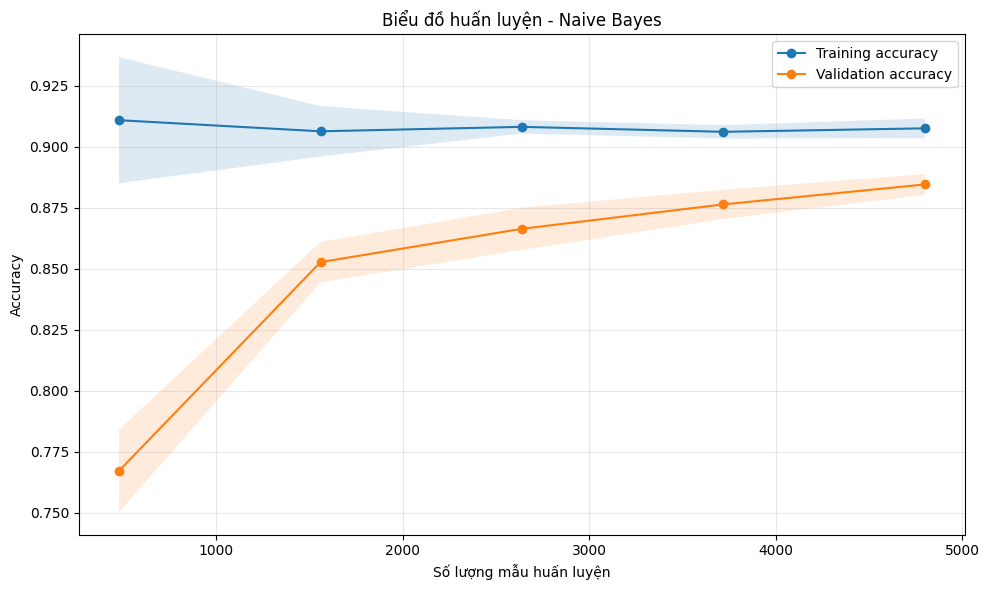

In [4]:
# Bước 4: Vector hóa, huấn luyện và đánh giá
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
display(nb_model)

y_pred = nb_model.predict(X_test)

print('--- KẾT QUẢ HUẤN LUYỆN NAIVE BAYES ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

labels = nb_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Ma trận nhầm lẫn - Naive Bayes')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

# Biểu đồ huấn luyện (learning curve)
train_sizes, train_scores, validation_scores = learning_curve(
    MultinomialNB(alpha=1.0),
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)
validation_scores_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training accuracy')
plt.plot(train_sizes, validation_scores_mean, marker='o', label='Validation accuracy')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.15)
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std, validation_scores_mean + validation_scores_std, alpha=0.15)
plt.title('Biểu đồ huấn luyện - Naive Bayes')
plt.xlabel('Số lượng mẫu huấn luyện')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()